# CNeuroMod QA — Motion-band composition

Per-run framewise displacement (FD) split into three exhaustive motion bands and
shown as stacked bars, one panel per dataset, one bar per subject:

- **% low motion** (FD ≤ 0.2 mm) = `1 - fd_prop_gt02`
- **% moderate motion** (0.2 < FD ≤ 0.5 mm) = `fd_prop_gt02 - fd_prop_gt05`
- **% high motion** (FD > 0.5 mm) = `fd_prop_gt05`

Bands are averaged over runs (each run weighted equally) within each
dataset × subject. Data is read from `output_data/tables/`; figures are written to
`output_data/figures/motion_bands/`. Parallels the FD figures in
`qc_measures.ipynb`.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt  # noqa: F401
import numpy as np
import pandas as pd

# The shared house style lives next to the notebooks (nbconvert runs with
# notebooks/ as the cwd, so `analysis` is not importable here); the sys.path
# line makes the import work when the notebook is opened from the repo root too.
sys.path.insert(0, str(Path.cwd()))
import figure_style  # noqa: E402
from figure_style import GRID, HUE, INK, MUTED, style_axes  # noqa: E402,F401

# Paths are provided by `invoke run-notebooks` as environment variables.
# Figures go in output_data/figures/{FIG_NAME}/ (also the notebook's "already
# ran" sentinel); the metric tables live in output_data/tables/.
FIG_NAME = "motion_bands"
OUTPUT_DIR = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data"))
FIG_DIR = OUTPUT_DIR / "figures" / FIG_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_tables(subdir):
    """Concatenate every non-empty TSV in output_data/<subdir>/."""
    frames = []
    for path in sorted((OUTPUT_DIR / subdir).glob("*.tsv")):
        try:
            frame = pd.read_csv(path, sep="\t")
        except (pd.errors.EmptyDataError, OSError):
            continue
        if not frame.empty:
            frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def panel(name, default, **kwargs):
    """A figure sized to the box the montage places `name` in (see figure_style).

    Neither of this notebook's figures is placed in the montage today, so both
    fall back to their default size — the call site is kept uniform with the
    other notebooks so a future placement needs no code change.
    """
    return plt.subplots(
        figsize=figure_style.panel_size(f"{FIG_NAME}/{name}", default),
        layout="constrained", **kwargs)


In [2]:
# Three motion bands (percent of volumes), derived from the two FD-proportion
# columns already persisted per run. The bands are exhaustive and sum to 100%.
# Colours are the dataviz status scale (good / warning / critical): an ordered
# severity ramp, kept CVD-safe by the fixed stacking order plus white gaps
# between segments (validated adjacent ΔE 11.3).
BANDS = [
    ("pct_low", "low (FD \u2264 0.2 mm)", "#0ca30c"),
    ("pct_mod", "moderate (0.2 < FD \u2264 0.5 mm)", "#fab219"),
    ("pct_high", "high (FD > 0.5 mm)", "#d03b3b"),
]

# CNeuroMod always has the same six subjects; keep every one on the x-axis even
# when a table only covers a subset, so figures are comparable across datasets.
SUBJECT_ROSTER = [1, 2, 3, 4, 5, 6]
SUBJECT_LABELS = [f"sub-{s:02d}" for s in SUBJECT_ROSTER]


def add_motion_bands(qc):
    """Add pct_low/pct_mod/pct_high columns; drop runs without FD proportions."""
    qc = qc.dropna(subset=["fd_prop_gt02", "fd_prop_gt05"]).copy()
    qc["pct_low"] = (1 - qc["fd_prop_gt02"]) * 100
    # Clip guards against tiny float rounding making the band slightly negative.
    qc["pct_mod"] = ((qc["fd_prop_gt02"] - qc["fd_prop_gt05"]) * 100).clip(lower=0)
    qc["pct_high"] = qc["fd_prop_gt05"] * 100
    return qc

In [3]:
qc = load_tables("tables")
print(f"loaded {len(qc)} runs")
if qc.empty:
    print("No QC metrics found — run `invoke run-qc-measures` first "
          "(needs data access).")
else:
    qc = add_motion_bands(qc)
    print(f"{len(qc)} runs with FD proportions")
qc.head()

loaded 4537 runs
3582 runs with FD proportions


,dataset,subject,session,task,run,task_grouped,fd_mean,fd_num,fd_perc,tsnr,...,dvars_vstd,aor,aqi,gcor,size_t,fd_prop_gt02,fd_prop_gt05,pct_low,pct_mod,pct_high
0,floc,1,1.0,fLoc,1.0,fLoc,0.095655,4,2.580645,34.775093,...,1.014164,0.001235,0.005645,0.005919,155,0.025806,0.000000,97.419355,2.580645,0.000000
1,floc,1,1.0,fLoc,2.0,fLoc,0.092470,3,1.935484,33.385800,...,0.989887,0.000598,0.006511,0.006913,155,0.019355,0.000000,98.064516,1.935484,0.000000
2,floc,1,2.0,fLoc,1.0,fLoc,0.107802,8,5.194805,32.012708,...,0.992889,0.000651,0.007349,0.004041,154,0.051948,0.000000,94.805195,5.194805,0.000000
3,floc,1,2.0,fLoc,2.0,fLoc,0.101230,12,7.792208,34.056397,...,1.020901,0.001314,0.005971,0.005213,154,0.077922,0.000000,92.207792,7.792208,0.000000
4,floc,1,3.0,fLoc,1.0,fLoc,0.115155,11,7.142857,30.349011,...,1.007480,0.001540,0.009845,0.003522,154,0.071429,0.006494,92.857143,6.493506,0.649351


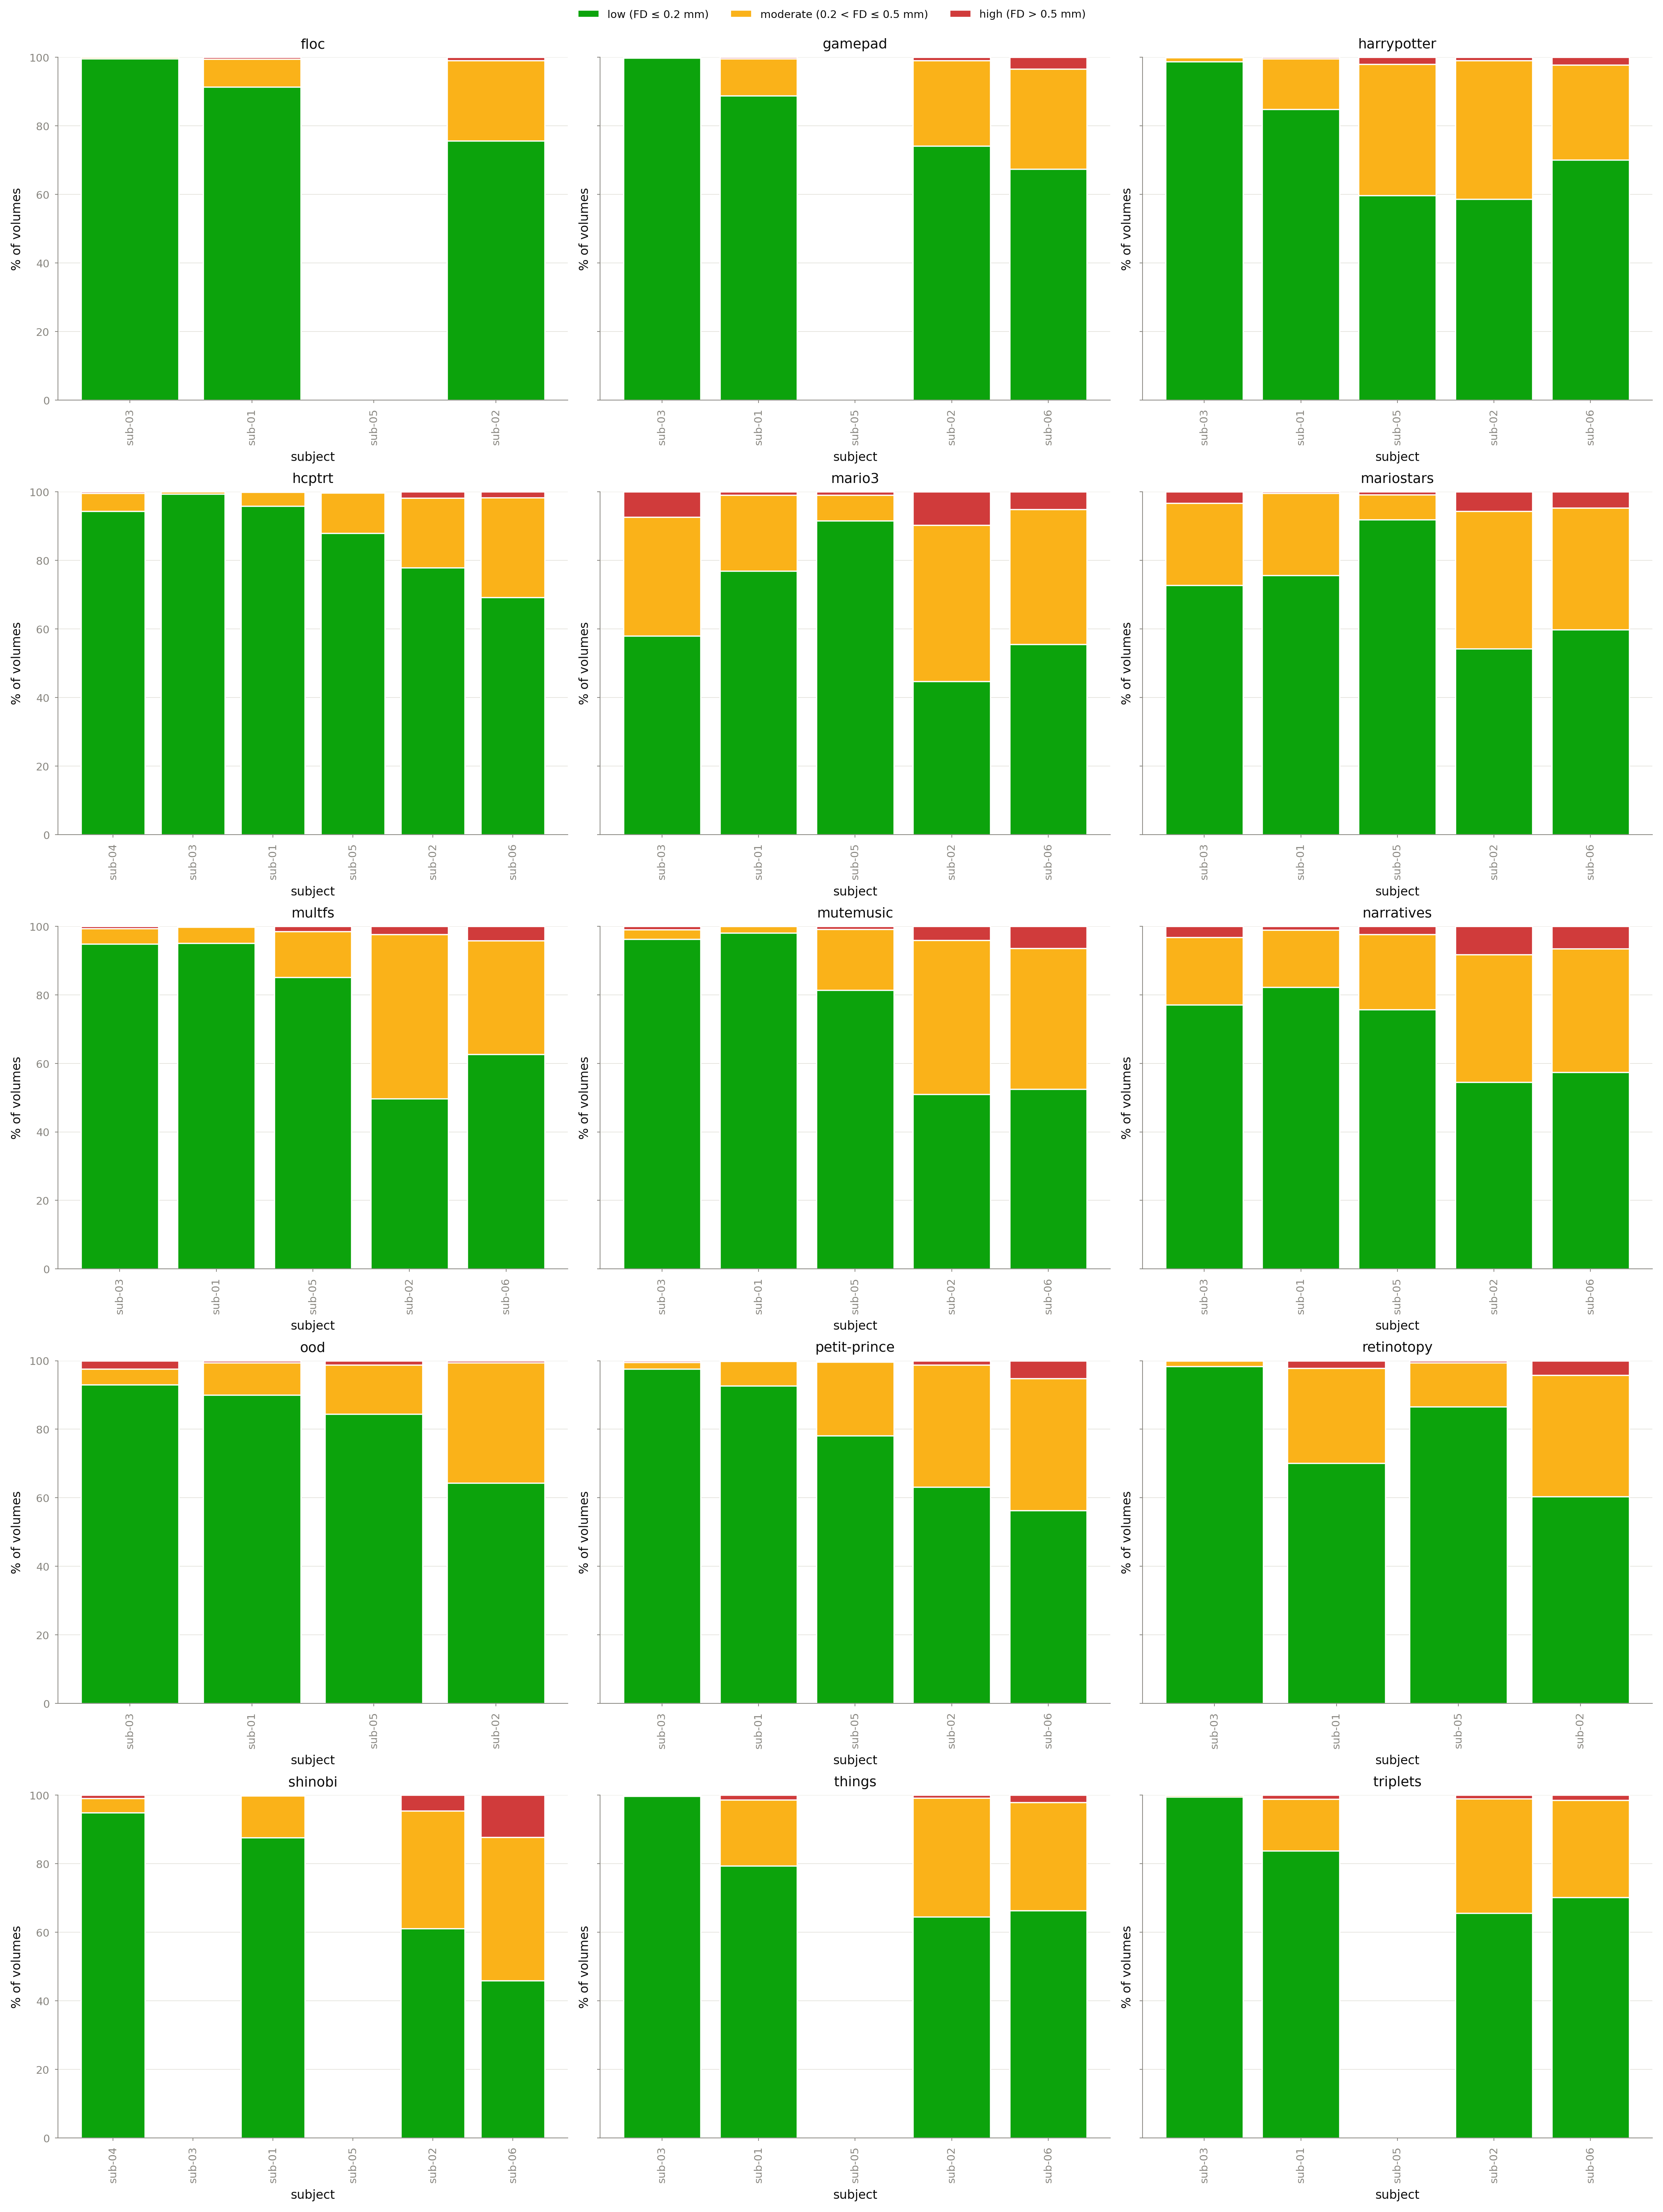

In [4]:
def stacked_motion_bars(grp, ax, subjects=SUBJECT_ROSTER):
    """Stacked low/moderate/high bars, one bar per subject in `subjects` order.

    A white edge on every segment leaves a surface gap between the stacked
    bands and between adjacent bars (dataviz spacer rule), which also gives the
    ordered status colours their secondary, colour-blind-safe separation."""
    labels = [f"sub-{s:02d}" for s in subjects]
    bottom = np.zeros(len(subjects))
    for col, label, color in BANDS:
        values = grp.reindex(subjects)[col].to_numpy(dtype=float)
        ax.bar(labels, values, bottom=bottom, color=color, label=label,
               edgecolor="white", linewidth=0.8)
        bottom += np.nan_to_num(values)
    ax.set_ylim(0, 100)
    ax.tick_params("x", labelrotation=90)
    style_axes(ax)


def motion_order(means):
    """Subjects ordered least-to-most motion (ascending non-low %), one global
    order shared by every panel so bars stay comparable across datasets.

    Motion is scored on the grand-average non-low share (moderate + high =
    100 - pct_low); roster subjects absent from the data sort last."""
    grand = means.groupby("subject")["pct_low"].mean()
    non_low = 100 - grand.reindex(SUBJECT_ROSTER)
    ordered = non_low.sort_values(na_position="last").index.tolist()
    return [int(s) for s in ordered]


if not qc.empty:
    band_cols = [col for col, _, _ in BANDS]
    means = (qc.groupby(["dataset", "subject"])[band_cols]
               .mean())
    datasets = sorted(means.index.get_level_values("dataset").unique())
    subject_order = motion_order(means)

    ncols = min(3, len(datasets))
    nrows = int(np.ceil(len(datasets) / ncols))
    fig, axes = panel("motion_bands_by_dataset_subject.png",
                      (5 * ncols, 4 * nrows), nrows=nrows, ncols=ncols,
                      squeeze=False, sharey=True)
    flat_axes = axes.flatten()

    for ax, dataset in zip(flat_axes, datasets):
        stacked_motion_bars(means.loc[dataset], ax, subjects=subject_order)
        ax.set_title(dataset)
        ax.set_ylabel("% of volumes")
        ax.set_xlabel("subject")

    for ax in flat_axes[len(datasets):]:
        ax.axis("off")

    handles, labels = flat_axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside upper center", ncol=3, frameon=False)
    fig.savefig(FIG_DIR / "motion_bands_by_dataset_subject.png",
                dpi=figure_style.PAGE_DPI)

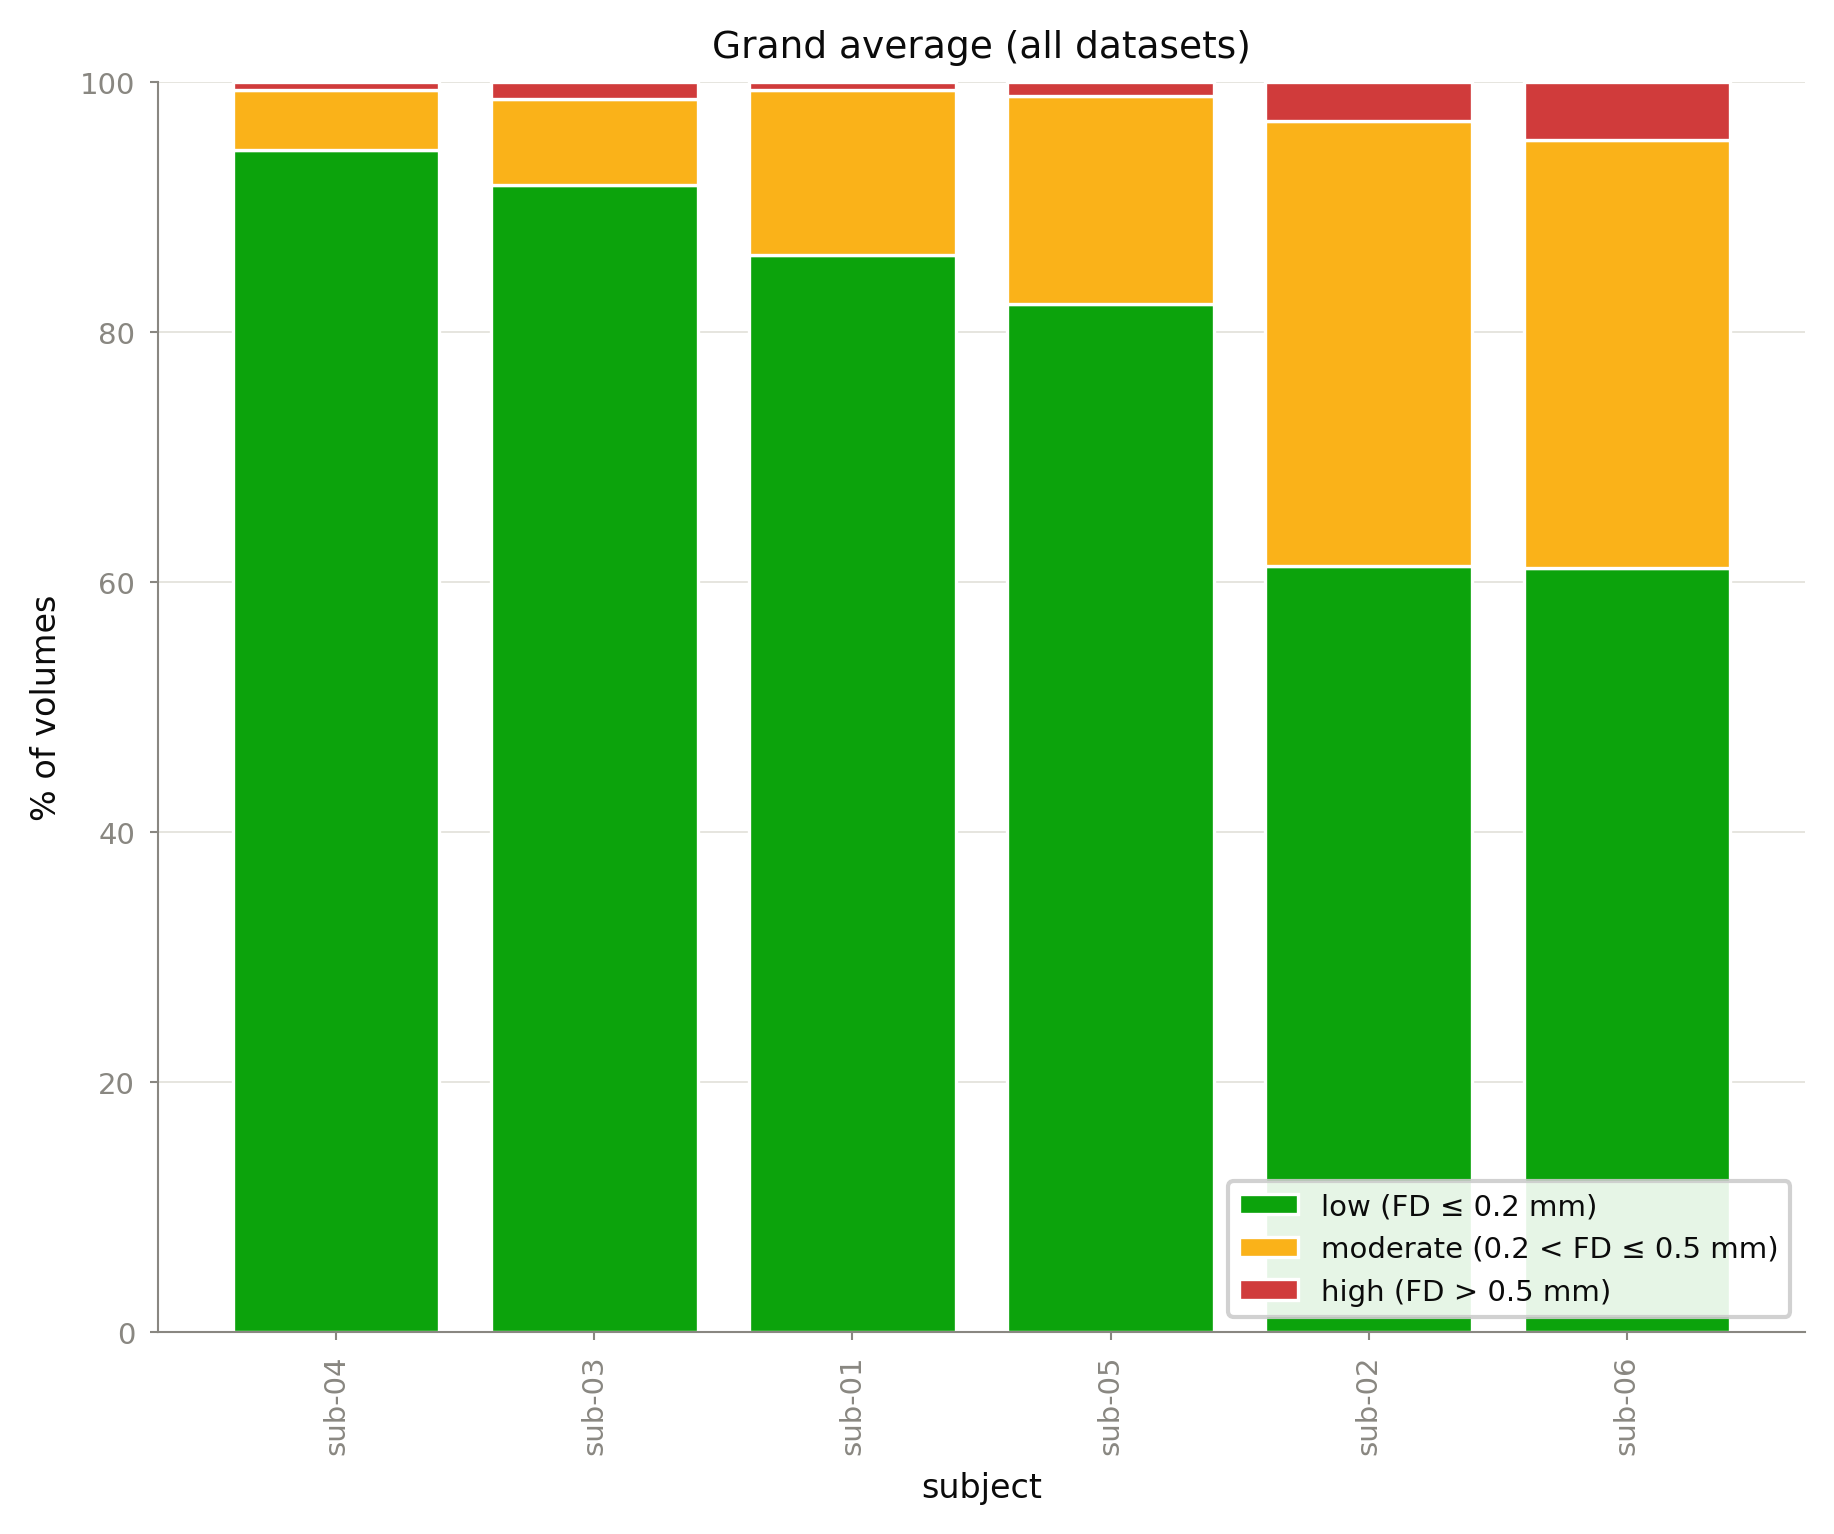

In [5]:
# Grand average: the per-dataset means averaged across datasets (each dataset
# weighted equally), giving one stacked bar per subject. Subjects share the same
# least-to-most-motion order as the per-dataset panels above.
if not qc.empty:
    grand = means.groupby("subject")[band_cols].mean()

    fig, ax = panel("motion_bands_grand_average.png",
                    (max(6, 0.6 * len(subject_order)), 5))
    stacked_motion_bars(grand, ax, subjects=subject_order)
    ax.set_title("Grand average (all datasets)")
    ax.set_ylabel("% of volumes")
    ax.set_xlabel("subject")
    ax.legend(loc="lower right", framealpha=0.9)
    fig.savefig(FIG_DIR / "motion_bands_grand_average.png",
                dpi=figure_style.PAGE_DPI)